# Notebook 08 — Exploratory Factor Analysis, PCA & Delay Cause Ranking

This notebook performs advanced exploratory analysis on the processed dataset of construction delay factors.  
Since the dataset is survey‑based and does not contain a target variable for supervised learning, this notebook focuses on **unsupervised analytical techniques** commonly used in construction delay research.

### **Objectives of Notebook 08**
- Understand relationships between delay factors  
- Identify underlying factor structures using PCA  
- Rank delay causes based on severity  
- Group similar delay factors using clustering  
- Generate a Delay Risk Index for each respondent  

These analyses provide deep insights into the major contributors to construction delays and support evidence‑based decision‑making.


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

plt.style.use("seaborn-v0_8")


In [35]:
# Load processed dataset from Notebook 07 (if saved), otherwise rebuild it.
from pathlib import Path
import sys

notebook_dir = Path.cwd()
project_root = notebook_dir.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

candidate_paths = [
    project_root / "data" / "processed" / "df_scaled.csv",
    project_root / "reports" / "df_scaled.csv",
    project_root / "df_scaled.csv",
]

existing_path = next((p for p in candidate_paths if p.exists()), None)

if existing_path is not None:
    df_scaled = pd.read_csv(existing_path)
    print(f"Loaded df_scaled from: {existing_path}")
else:
    from src.ingestion.file_loader import load_file
    from src.preparation.cleaning import clean_dataset
    from src.preparation.encoding import encode_categorical, scale_numerical

    raw_csv = project_root.parent / "archive(1)" / "Road Constuction Delay Survey.csv"
    df_raw = load_file(str(raw_csv))

    df_raw.columns = [col.strip() if isinstance(col, str) else col for col in df_raw.columns]
    if "Respondent Number" in df_raw.columns:
        respondent_num = pd.to_numeric(df_raw["Respondent Number"], errors="coerce")
        df_raw = df_raw[respondent_num.notna()].copy()

    df_clean = clean_dataset(df_raw)
    df_encoded, _ = encode_categorical(df_clean, categorical_columns=[])
    df_scaled, _ = scale_numerical(df_encoded, numeric_columns=["Respondent Number"])

    save_path = project_root / "data" / "processed" / "df_scaled.csv"
    save_path.parent.mkdir(parents=True, exist_ok=True)
    df_scaled.to_csv(save_path, index=False)
    print(f"Rebuilt df_scaled and saved to: {save_path}")

df = df_scaled.copy()
print("Dataset loaded for Notebook 08.")
df_scaled.head()


Loaded df_scaled from: c:\Users\olive\Desktop\My ML Material\CONSTRUCTION DELAY RISK PREDICTION SYSTEM\CDRPS\data\processed\df_scaled.csv
Dataset loaded for Notebook 08.


,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 8: Scope of work.3,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5
0,-1.719981,1,1,1,1,1,1,1,1,1,...,1,2,2,3,1,2,2,2,3,5
1,-1.695756,2,5,3,2,3,2,2,2,3,...,3,1,1,4,1,3,2,3,3,3
2,-1.671530,1,2,1,1,2,2,1,2,1,...,2,1,1,4,1,2,2,1,2,4
3,-1.647305,2,2,3,3,2,2,3,4,4,...,3,4,3,3,1,3,1,1,3,4
4,-1.623080,1,2,1,1,2,2,1,2,1,...,2,1,1,4,1,2,3,1,2,4


In [36]:
df = df_scaled.copy()
print("Dataset loaded for Notebook 08.")
df.head()


Dataset loaded for Notebook 08.


,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 8: Scope of work.3,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5
0,-1.719981,1,1,1,1,1,1,1,1,1,...,1,2,2,3,1,2,2,2,3,5
1,-1.695756,2,5,3,2,3,2,2,2,3,...,3,1,1,4,1,3,2,3,3,3
2,-1.671530,1,2,1,1,2,2,1,2,1,...,2,1,1,4,1,2,2,1,2,4
3,-1.647305,2,2,3,3,2,2,3,4,4,...,3,4,3,3,1,3,1,1,3,4
4,-1.623080,1,2,1,1,2,2,1,2,1,...,2,1,1,4,1,2,3,1,2,4


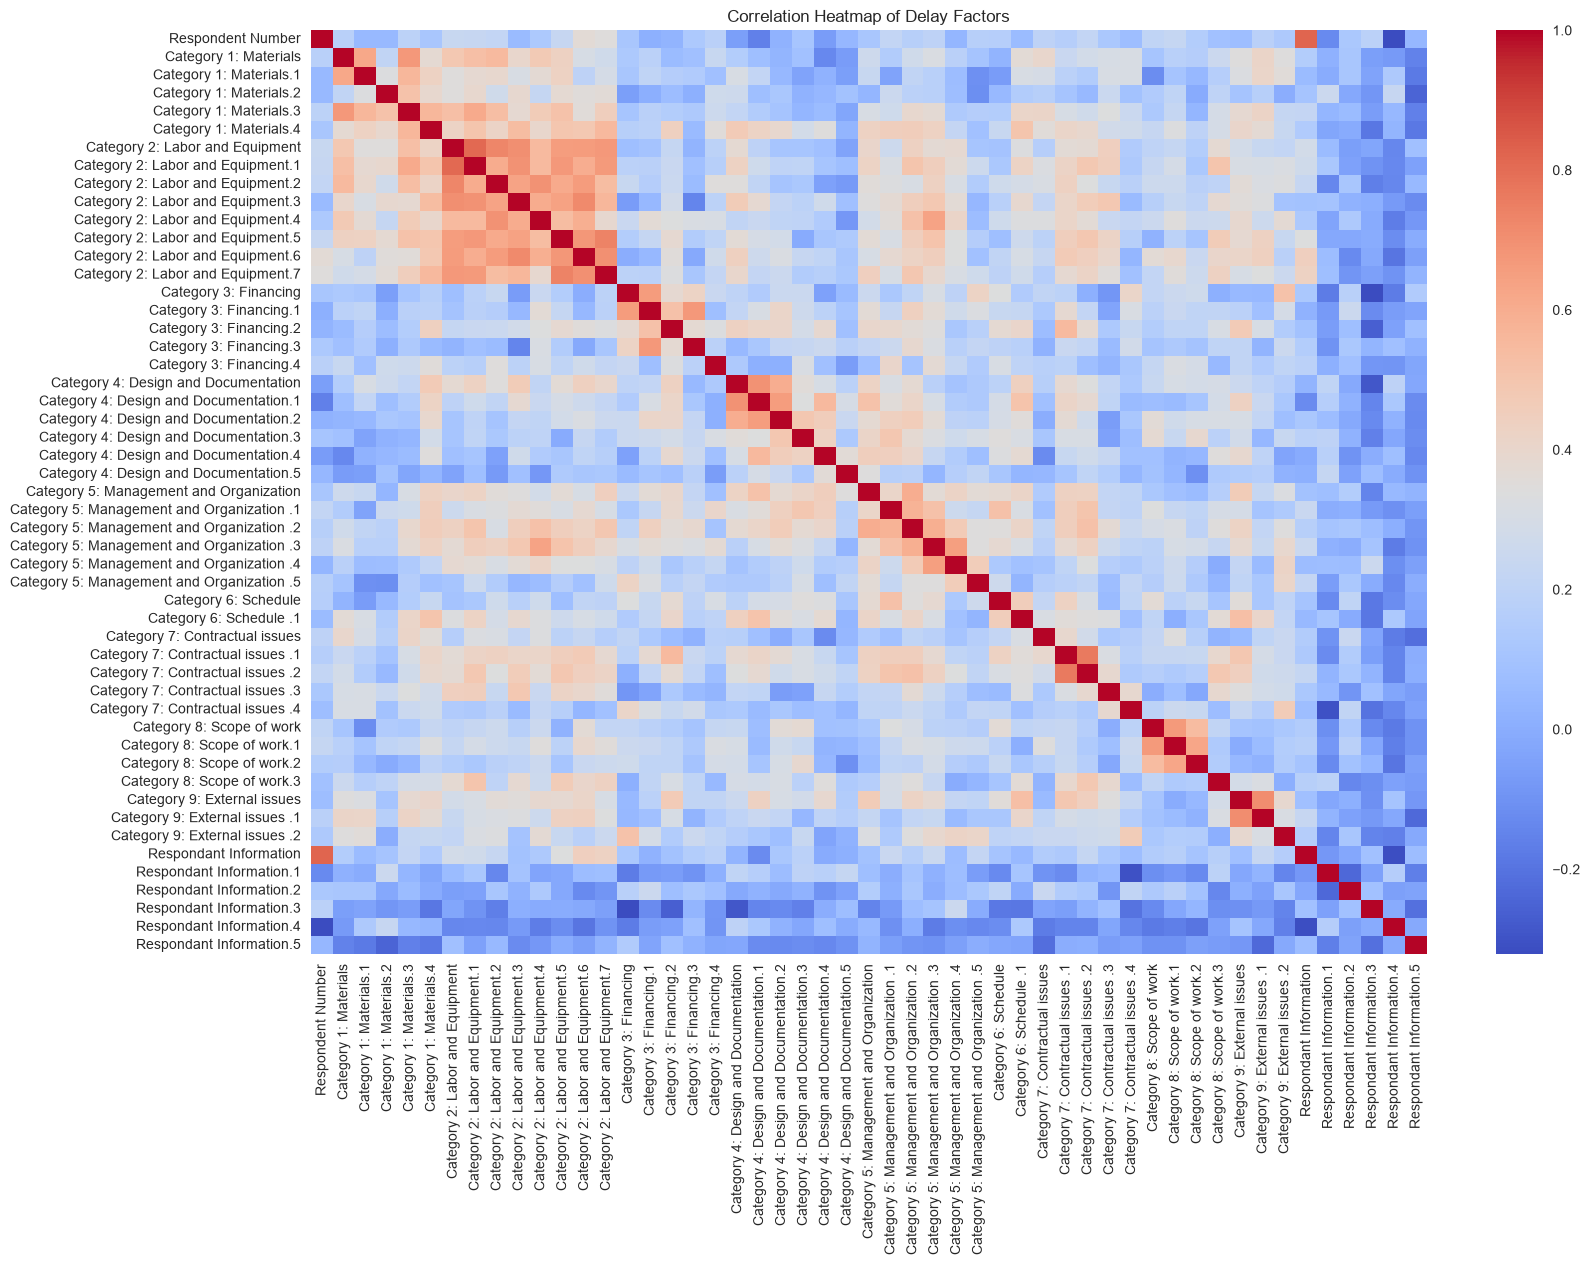

In [37]:
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Delay Factors")
plt.show()


In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaling completed for PCA.")


Scaling completed for PCA.


In [39]:
#impute missing values with mean

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


In [40]:
pca = PCA(n_components=5)
pca_components = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
explained_variance


array([0.26435194, 0.08042991, 0.06979414, 0.05268827, 0.04463661])

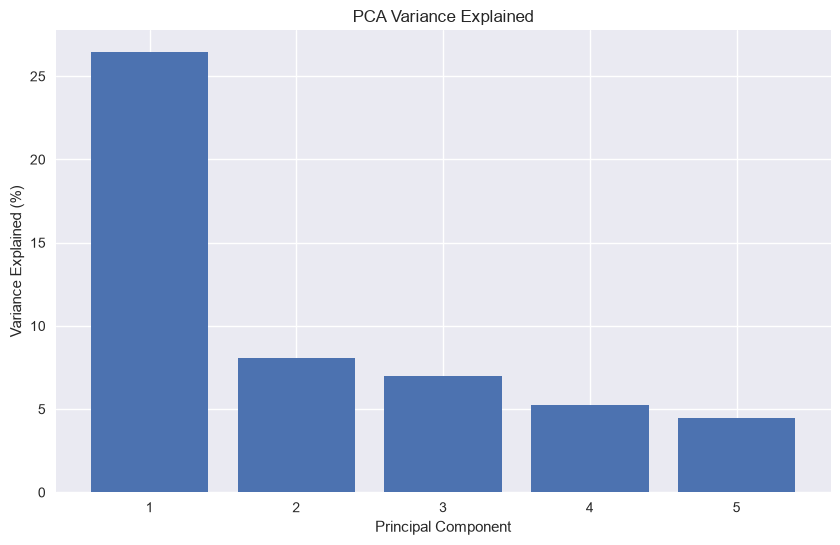

In [41]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), explained_variance * 100)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("PCA Variance Explained")
plt.show()


In [42]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(5)],
    index=df.columns
)

loadings


,PC1,PC2,PC3,PC4,PC5
Respondent Number,0.078038,-0.068341,-0.233639,-0.223788,-0.157780
Category 1: Materials,0.146308,-0.199161,-0.104140,0.222211,0.047153
Category 1: Materials.1,0.120148,-0.186547,0.010739,0.345033,0.069328
Category 1: Materials.2,0.099452,-0.181513,0.080715,-0.006238,0.218197
Category 1: Materials.3,0.167963,-0.196416,-0.031668,0.173336,0.067179
Category 1: Materials.4,0.192355,-0.043080,0.072430,0.051842,0.176966
Category 2: Labor and Equipment,0.186657,-0.223658,-0.016832,-0.074095,-0.026592
Category 2: Labor and Equipment.1,0.206424,-0.180449,0.000255,-0.033722,-0.022425
Category 2: Labor and Equipment.2,0.187048,-0.166418,-0.116645,0.029182,0.068233
Category 2: Labor and Equipment.3,0.191287,-0.181509,0.110016,-0.112267,0.050803


In [43]:
numeric_df = df.select_dtypes(include=["number"])
factor_scores = numeric_df.mean().sort_values(ascending=False)
factor_scores

Category 8: Scope of work.1                   4.069930e+00
Respondant Information.5                      4.048951e+00
Category 5: Management and Organization .5    4.027972e+00
Category 8: Scope of work                     3.944056e+00
Category 8: Scope of work.2                   3.909091e+00
Category 4: Design and Documentation          3.805755e+00
Category 2: Labor and Equipment.6             3.790210e+00
Category 2: Labor and Equipment.7             3.769231e+00
Category 7: Contractual issues .3             3.664336e+00
Category 9: External issues .2                3.664336e+00
Category 7: Contractual issues .4             3.650350e+00
Category 4: Design and Documentation.4        3.636364e+00
Category 3: Financing.1                       3.629371e+00
Category 4: Design and Documentation.3        3.622378e+00
Category 3: Financing                         3.608392e+00
Category 3: Financing.3                       3.580420e+00
Category 8: Scope of work.3                   3.559441e+

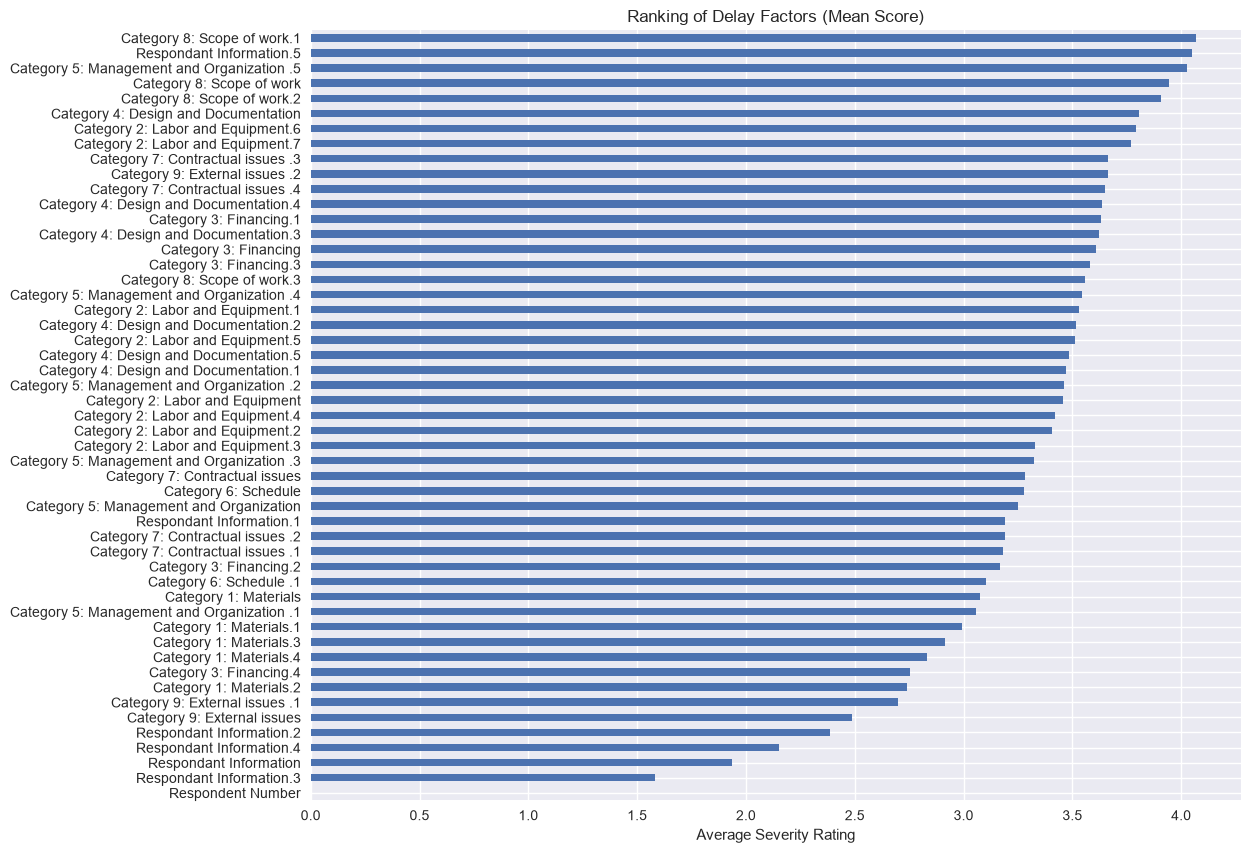

In [44]:
plt.figure(figsize=(12, 10))
factor_scores.plot(kind="barh")
plt.title("Ranking of Delay Factors (Mean Score)")
plt.xlabel("Average Severity Rating")
plt.gca().invert_yaxis()
plt.show()


In [45]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_clusters = df.copy()
df_clusters["Cluster"] = clusters
df_clusters.head()


,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5,Cluster
0,-1.719981,1,1,1,1,1,1,1,1,1,...,2,2,3,1,2,2,2,3,5,2
1,-1.695756,2,5,3,2,3,2,2,2,3,...,1,1,4,1,3,2,3,3,3,1
2,-1.671530,1,2,1,1,2,2,1,2,1,...,1,1,4,1,2,2,1,2,4,2
3,-1.647305,2,2,3,3,2,2,3,4,4,...,4,3,3,1,3,1,1,3,4,1
4,-1.623080,1,2,1,1,2,2,1,2,1,...,1,1,4,1,2,3,1,2,4,2


In [46]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df.columns
)

cluster_centers


,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 8: Scope of work.3,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5
0,0.099824,0.336423,0.497829,0.031065,0.373906,0.519851,0.453556,0.525282,0.410906,0.414124,...,0.442234,0.701068,0.510969,0.573503,0.129896,-0.052161,0.169670,-0.082048,-0.040338,-0.105495
1,-0.074639,-0.018185,-0.055701,-0.228724,-0.253628,-0.708131,-0.591355,-0.652460,-0.267789,-0.429850,...,-0.827605,-0.478376,-0.380222,-0.162217,-0.276451,-0.392909,0.316288,0.459776,0.042998,-0.067974
2,-0.935461,-1.468027,-1.151388,-1.356052,-1.598306,-1.279589,-1.548183,-1.678505,-1.888474,-1.932913,...,-0.540417,-0.929416,-0.824261,-0.816430,-0.839181,0.208828,-0.398954,-0.487120,0.280752,0.437945
3,0.260939,0.006991,-0.338432,0.693990,0.242162,0.362404,0.448579,0.442721,0.303595,0.486089,...,0.342779,-0.310847,-0.138646,-0.475643,0.388687,0.424235,-0.467346,-0.169154,-0.082889,0.084014


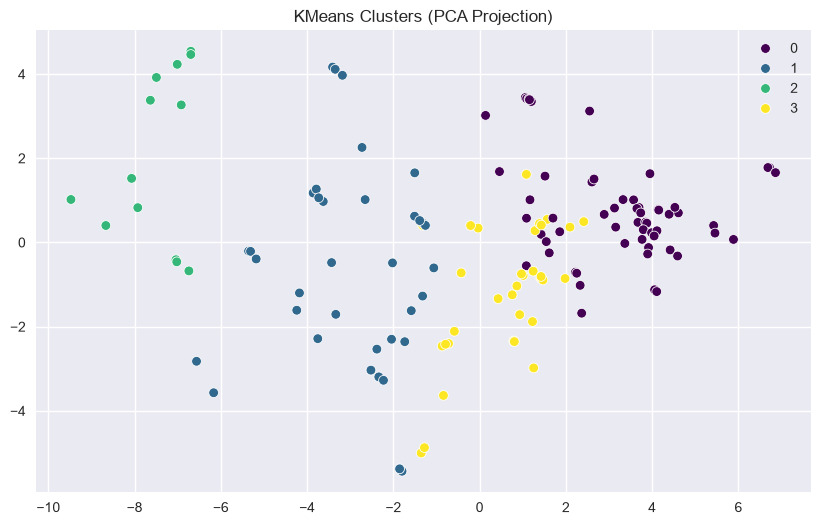

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pca_components[:, 0],
    y=pca_components[:, 1],
    hue=clusters,
    palette="viridis"
)
plt.title("KMeans Clusters (PCA Projection)")
plt.show()


In [48]:
candidate_cols = [col for col in df.columns if col != "Respondent Number"]
risk_features = df[candidate_cols].apply(pd.to_numeric, errors="coerce")
risk_features = risk_features.loc[:, risk_features.notna().any(axis=0)]

if risk_features.shape[1] == 0:
    raise ValueError("No valid numeric delay-factor columns were found to build Delay_Risk_Index.")

df["Delay_Risk_Index"] = risk_features.mean(axis=1, skipna=True)
df["Delay_Risk_Index"].describe()

count    143.000000
mean       3.293472
std        0.518207
min        1.960000
25%        2.990000
50%        3.400000
75%        3.727347
max        4.260000
Name: Delay_Risk_Index, dtype: float64

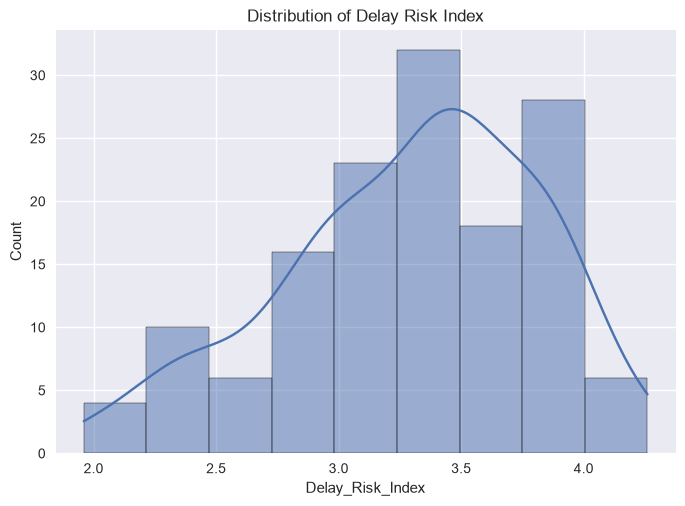

In [ ]:
sns.histplot(df["Delay_Risk_Index"], kde=True) # type: ignore
plt.title("Distribution of Delay Risk Index")
plt.show()
